In [100]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict

# Hyperparameters
velocity = 1.0
num_epochs = 2000
nu = 0.1

In [101]:
def analytical_solution(t, x):
    # u solution - 位移
    u = 0.5 * (torch.sin(torch.pi * (x + t)) + torch.sin(torch.pi * (x - t)))
    # v = u_t solution - 速度
    v = 0.5 * torch.pi * (torch.cos(torch.pi * (x + t)) - torch.cos(torch.pi * (x - t)))
    return torch.cat([u, v], dim=1)

class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2)  # 输出两个变量: u和v
        self.tanh = nn.Tanh()

    def forward(self, x, t=None):
        if t is not None:
            # 分开的x和t作为输入
            inputs = torch.cat([t, x], dim=1)  # 注意顺序是[t,x]
        else:
            # 已经组合的输入
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out


In [102]:
# 从sampling_PDE.py引入的DNN类
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

# MMPDE采样类
class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        # 数据
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络
        self.dnn = DNN(layers)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        # 计算u对t的一阶导数
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对t的二阶导数(utt)
        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的一阶导数
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的二阶导数(uxx)
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        w = (1 + (u_x) ** 2 + (0.5 * u_tt ** 2)) ** (1 / 2)
        
        return w

    def net_sample(self, t, x):
        # 生成新的采样点
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        # 计算MMPDE方程的残差
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算解及其导数
        u = self.fun(torch.cat([t, x], dim=1))
        
        # 直接调用修改后的monitor函数，传入u,t,x
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 不再需要G_tx的计算，因为我们已经在monitor函数中处理了二阶导数

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        # 计算损失函数
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        # 训练过程
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        # 返回新的采样点
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [103]:
def create_simulation_function(model=None):
    # 如果没有提供模型，则使用解析解
    def simulation_function(xt):
        t, x = xt[:, 0:1], xt[:, 1:2]
        return 0.5 * (torch.sin(torch.pi * (x + t)) + torch.sin(torch.pi * (x - t)))
        
    return simulation_function

开始MMPDE训练...
MMPDE_Adam Iter 100, Loss: 26.284515
Time: 0.6654s
MMPDE_Adam Iter 200, Loss: 7.365163
Time: 0.6010s
MMPDE_Adam Iter 300, Loss: 3.581325
Time: 0.6316s
MMPDE_Adam Iter 400, Loss: 3.108257
Time: 0.6538s
MMPDE_Adam Iter 500, Loss: 2.884122
Time: 0.6382s
MMPDE_Adam Iter 600, Loss: 2.686075
Time: 0.6318s
MMPDE_Adam Iter 700, Loss: 2.412037
Time: 0.5967s
MMPDE_Adam Iter 800, Loss: 1.929544
Time: 0.6234s
MMPDE_Adam Iter 900, Loss: 1.194470
Time: 0.5976s
MMPDE_Adam Iter 1000, Loss: 0.769386
Time: 0.6301s
MMPDE_Adam Iter 1100, Loss: 0.563040
Time: 0.5807s
MMPDE_Adam Iter 1200, Loss: 0.439269
Time: 0.5946s
MMPDE_Adam Iter 1300, Loss: 0.397338
Time: 0.6212s
MMPDE_Adam Iter 1400, Loss: 0.391438
Time: 0.6305s
MMPDE_Adam Iter 1500, Loss: 0.374106
Time: 0.5997s
MMPDE_Adam Iter 1600, Loss: 0.368601
Time: 0.6004s
MMPDE_Adam Iter 1700, Loss: 0.368875
Time: 0.5939s
MMPDE_Adam Iter 1800, Loss: 0.376375
Time: 0.5925s
MMPDE_Adam Iter 1900, Loss: 0.356824
Time: 0.5974s
MMPDE_Adam Iter 2000, Loss

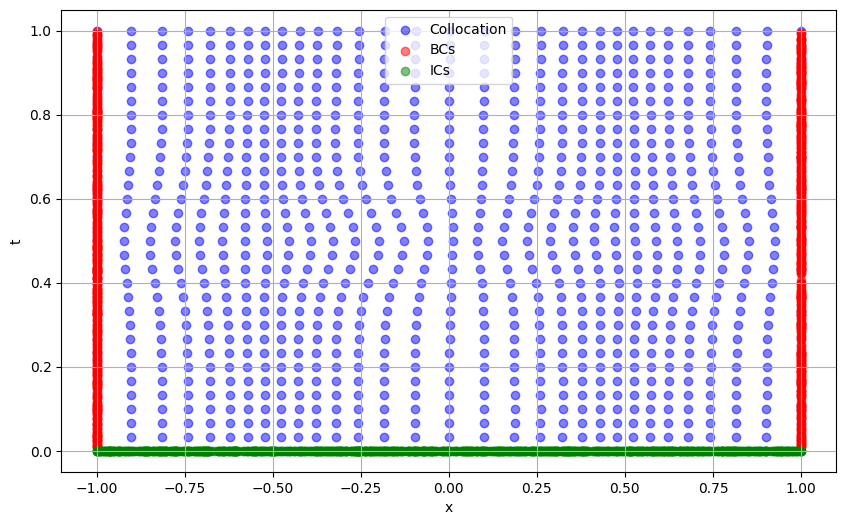

In [104]:
lb = [0.0, -1.0]  # [t_min, x_min]
ub = [1.0, 1.0]   # [t_max, x_max]

# 生成均匀分布的采样点
num_samples_per_dim = int(np.sqrt(1000))  # 每个维度上采样约100个点
x_uniform = torch.linspace(-1, 1, num_samples_per_dim)
t_uniform = torch.linspace(0, 1, num_samples_per_dim)

# 创建均匀网格
X_grid, T_grid = torch.meshgrid(x_uniform, t_uniform, indexing='ij')
x_init = X_grid.reshape(-1, 1)
t_init = T_grid.reshape(-1, 1)

# 合并为输入样本
X_f_init = torch.cat([t_init, x_init], dim=1).numpy()

# 创建模拟函数
sim_func = create_simulation_function()

# 定义MMPDE参数
mmpde_layers = [2, 20, 20, 20, 1]  # 输入(t,x)，输出新的x坐标
adam_iter = 2000
lbfgs_iter = 500

# 创建MMPDE采样器并训练
mmpde_sampler = sampling_MMPDE(
    X_f=X_f_init,
    u_fun=sim_func,
    layers=mmpde_layers,
    lb=lb,
    ub=ub,
    nu=nu,
    AdamIter=adam_iter,
    LBFGSIter=lbfgs_iter
)

# 训练MMPDE并获取优化后的采样点
new_samples = mmpde_sampler.train()

# 提取优化后的采样点
t_colloc = new_samples[:, 0:1].clone().detach().requires_grad_(True)
x_colloc = new_samples[:, 1:2].clone().detach().requires_grad_(True)
x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)

# 生成边界条件点
N_bc = 1000
t_bc = torch.rand(N_bc, 1) * (ub[0] - lb[0]) + lb[0]  # t ∈ [t_min, t_max]
x_bc_left = -torch.ones(N_bc//2, 1) 
x_bc_right = torch.ones(N_bc//2, 1)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_split = torch.split(t_bc, N_bc//2)
x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
x_bc_combined.requires_grad_(True)

# 初始条件点(t=0)
N_ic = 1000
x_ic = torch.rand(N_ic, 1) * 2 - 1  # x ∈ [-1, 1]
t_ic = torch.zeros(N_ic, 1)
x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
x_ic_combined.requires_grad_(True)

# 可视化采样点
plt.figure(figsize=(10, 6))
plt.scatter(x_colloc.detach().numpy(), t_colloc.detach().numpy(), color='blue', alpha=0.5, label='Collocation')
plt.scatter(x_bc.detach().numpy(), t_bc.detach().numpy(), color='red', alpha=0.5, label='BCs')
plt.scatter(x_ic.detach().numpy(), t_ic.detach().numpy(), color='green', alpha=0.5, label='ICs')
plt.xlabel('x')
plt.ylabel('t')
plt.legend()
plt.grid(True)
plt.show()

In [105]:
def x_f_loss_fun(inputs, model):
    """
    计算PDE残差，使用u_t=v和v_t=c^2*u_xx形式
    """
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)
    
    # 获取模型预测的u和v
    uv = model(inputs)
    u = uv[:, 0:1]  # 提取u
    v = uv[:, 1:2]  # 提取v
    
    # 分别计算u和v关于输入(t,x)的导数
    
    # 计算u关于输入的梯度
    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  # 第一列是关于t的导数
    u_x = u_grad[:, 1:2]  # 第二列是关于x的导数
    
    # 计算v关于t的导数
    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1]  # 关于t的导数
    
    # 计算u_xx - 对u_x再求一次关于x的导数
    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    # 计算残差
    f_u = u_t - v          # u_t = v
    f_v = v_t - velocity**2 * u_xx  # v_t = c^2*u_xx
    
    return f_u, f_v

def pde_residual(model, x_colloc, velocity):
    """计算PDE方程组的残差"""
    f_u, f_v = x_f_loss_fun(x_colloc, model, velocity)
    loss = torch.mean(f_u**2) + torch.mean(f_v**2)
    return loss

In [106]:
def boundary_loss(model, x_bc):
    """边界条件损失：u在边界上为0"""
    outputs = model(x_bc)
    u = outputs[:, 0:1]  # 只取u值
    return torch.mean(u**2)

def initial_condition_loss(model, x_ic):
    """
    初始条件损失：
    1. u(x,0) = sin(pi*x)
    2. v(x,0) = 0 (初始速度为0)
    """
    outputs = model(x_ic)
    u = outputs[:, 0:1]
    v = outputs[:, 1:2]
    
    # 提取x坐标
    x = x_ic[:, 1:2]
    
    # 计算初始条件误差
    u_ic_target = torch.sin(torch.pi * x)
    v_ic_target = torch.zeros_like(v)  # v初始为0
    
    u_loss = torch.mean((u - u_ic_target)**2)
    v_loss = torch.mean((v - v_ic_target)**2)
    
    return u_loss + v_loss


In [107]:
# 创建模型和优化器
model = PINN(2, 40)  # 输入维度是2 (t和x)，隐藏层维度40
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

# 训练循环
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # 计算PDE残差
    f_u, f_v = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f_u**2) + torch.mean(f_v**2)
    
    # 计算边界条件损失
    outputs_bc = model(x_bc_combined)
    u_bc = outputs_bc[:, 0:1]  # 只取u值
    loss_bc = torch.mean(u_bc**2)
    
    # 计算初始条件损失
    outputs_ic = model(x_ic_combined)
    u_ic = outputs_ic[:, 0:1]
    v_ic = outputs_ic[:, 1:2]
    
    # 提取x坐标
    x_coord = x_ic_combined[:, 1:2]
    
    # 计算初始条件误差
    u_ic_target = torch.sin(torch.pi * x_coord)
    v_ic_target = torch.zeros_like(v_ic)  # v初始为0
    
    u_loss = torch.mean((u_ic - u_ic_target)**2)
    v_loss = torch.mean((v_ic - v_ic_target)**2)
    loss_ic = u_loss + v_loss
    
    # 总损失
    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}/{num_epochs}, "
              f"Loss: {total_loss.item():.6f}, "
              f"PDE: {loss_pde.item():.6f}, "
              f"BC: {loss_bc.item():.6f}, "
              f"IC: {loss_ic.item():.6f}")

Epoch: 0/2000, Loss: 5.389387, PDE: 0.022572, BC: 0.013265, IC: 0.523417
Epoch: 100/2000, Loss: 2.377502, PDE: 0.371182, BC: 0.042376, IC: 0.158256
Epoch: 200/2000, Loss: 1.264653, PDE: 0.534445, BC: 0.013679, IC: 0.059342
Epoch: 300/2000, Loss: 0.558533, PDE: 0.257660, BC: 0.019386, IC: 0.010701
Epoch: 400/2000, Loss: 0.338737, PDE: 0.146702, BC: 0.012622, IC: 0.006582
Epoch: 500/2000, Loss: 0.234540, PDE: 0.107752, BC: 0.009092, IC: 0.003586
Epoch: 600/2000, Loss: 0.196476, PDE: 0.092812, BC: 0.007395, IC: 0.002971
Epoch: 700/2000, Loss: 0.161301, PDE: 0.078440, BC: 0.005801, IC: 0.002486
Epoch: 800/2000, Loss: 0.128811, PDE: 0.064788, BC: 0.004415, IC: 0.001988
Epoch: 900/2000, Loss: 0.103467, PDE: 0.053597, BC: 0.003263, IC: 0.001724
Epoch: 1000/2000, Loss: 0.083675, PDE: 0.045664, BC: 0.002600, IC: 0.001201
Epoch: 1100/2000, Loss: 0.075326, PDE: 0.042122, BC: 0.002266, IC: 0.001055
Epoch: 1200/2000, Loss: 0.067355, PDE: 0.038640, BC: 0.001955, IC: 0.000916
Epoch: 1300/2000, Loss: 

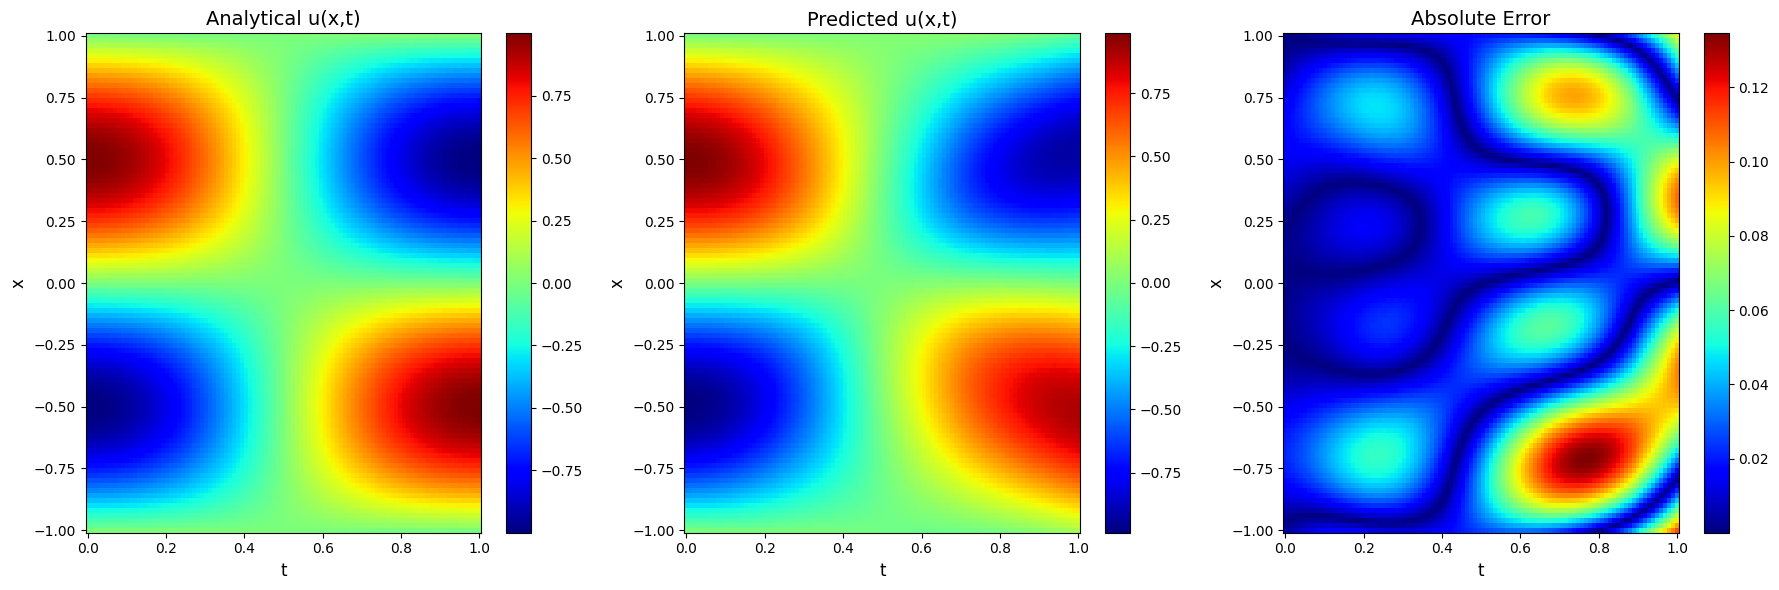

总体u的L2误差: 0.044591


In [108]:
# 创建网格点
nx, nt = 100, 100
x = torch.linspace(-1, 1, nx).reshape(-1, 1)
t = torch.linspace(0, 1, nt).reshape(-1, 1)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    uv_pred = model(X_test)

u_pred = uv_pred[:, 0].reshape(nx, nt).detach().numpy()
v_pred = uv_pred[:, 1].reshape(nx, nt).detach().numpy()

# 解析解
uv_exact = analytical_solution(T_flat, X_flat)
u_exact = uv_exact[:, 0].reshape(nx, nt).detach().numpy()
v_exact = uv_exact[:, 1].reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)

# 显示热图对比
plt.figure(figsize=(18, 6))

plt.subplot(131)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical u(x,t)', fontsize=14)

plt.subplot(132)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted u(x,t)', fontsize=14)

plt.subplot(133)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
print(f"总体u的L2误差: {total_u_l2_error:.6f}")

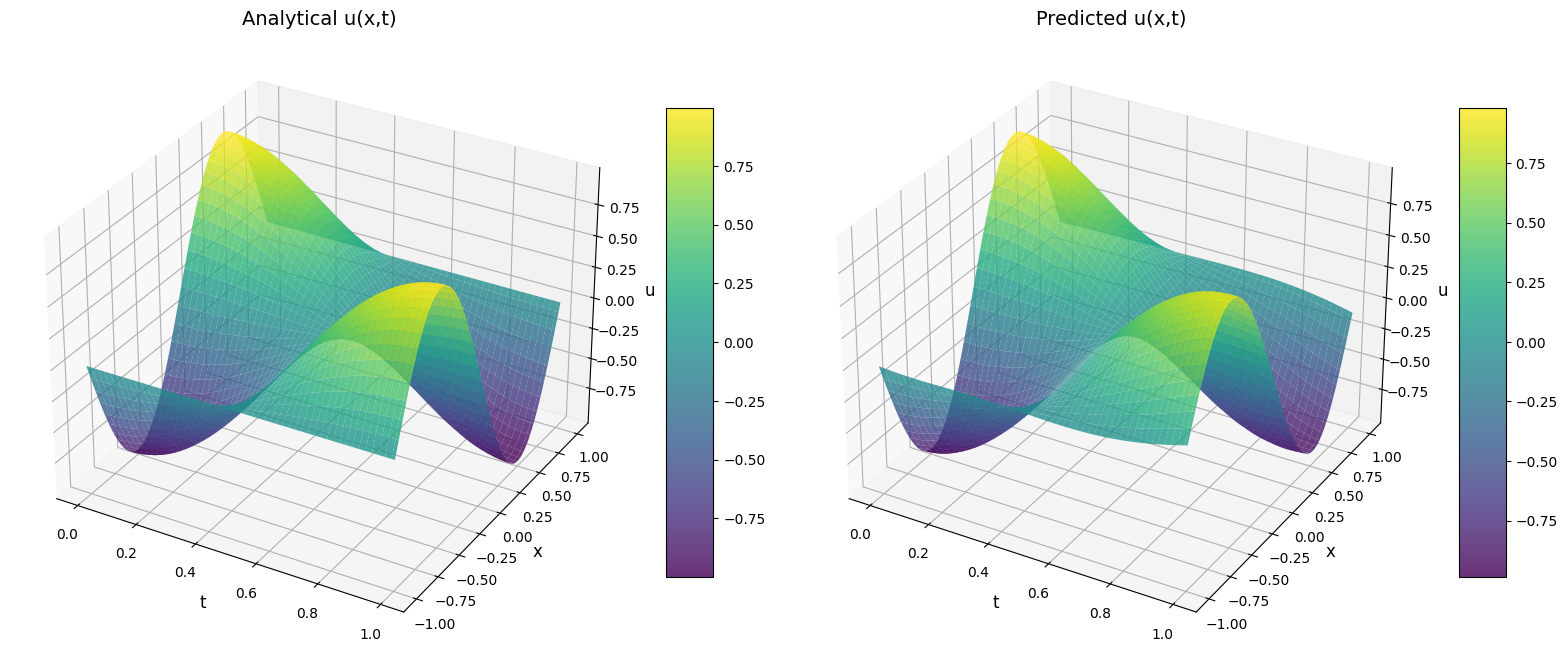

In [109]:
# 3D表面图对比 - 展示u解的三维视图
fig = plt.figure(figsize=(16, 7))

# 解析解的3D表面图
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(T.numpy(), X.numpy(), u_exact, cmap='viridis', 
                       linewidth=0, antialiased=True, alpha=0.8)
fig.colorbar(surf1, ax=ax1, shrink=0.7, aspect=10)
ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('x', fontsize=12)
ax1.set_zlabel('u', fontsize=12)
ax1.set_title('Analytical u(x,t)', fontsize=14)

# 预测值的3D表面图
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(T.numpy(), X.numpy(), u_pred, cmap='viridis', 
                       linewidth=0, antialiased=True, alpha=0.8)
fig.colorbar(surf2, ax=ax2, shrink=0.7, aspect=10)
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('x', fontsize=12)
ax2.set_zlabel('u', fontsize=12)
ax2.set_title('Predicted u(x,t)', fontsize=14)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


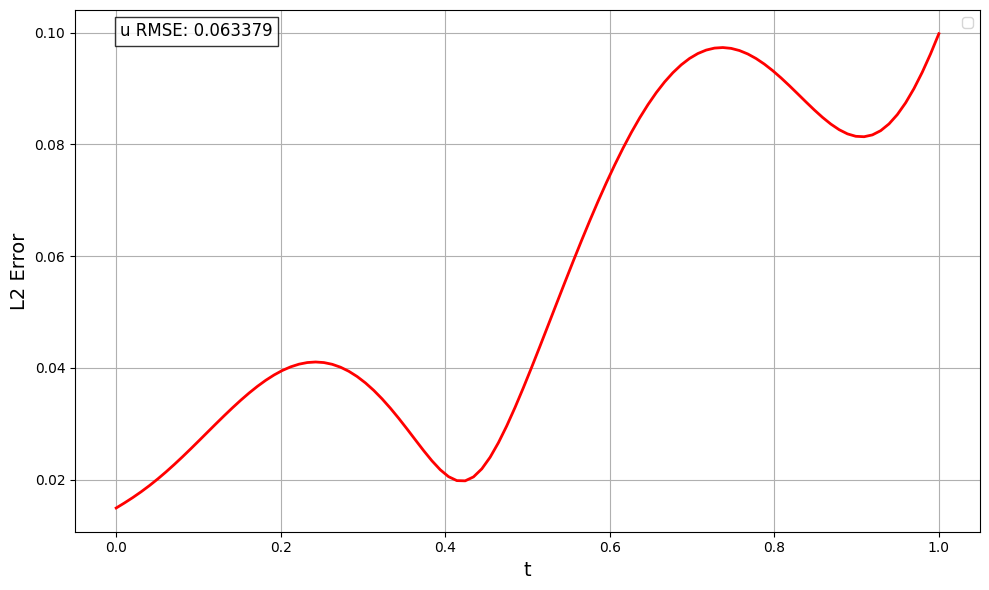

In [110]:
def compute_and_plot_l2_error(u_analytical, u_predicted, t_points, x_range):
    """计算并绘制不同时间点上的L2误差"""
    # 计算空间步长(用于数值积分)
    dx = (x_range[1] - x_range[0]) / (u_analytical.shape[0] - 1)
    
    # 初始化L2误差数组
    l2_errors_u = np.zeros(len(t_points))
    
    # 对每个时间点计算L2误差
    for i in range(len(t_points)):
        # 计算u的L2误差
        squared_error_u = (u_analytical[:, i] - u_predicted[:, i])**2
        l2_errors_u[i] = np.sqrt(np.sum(squared_error_u) * dx)
    
    # 绘制L2误差随时间的变化
    plt.figure(figsize=(10, 6))
    plt.plot(t_points, l2_errors_u, 'r-', linewidth=2)
    plt.grid(True)
    plt.xlabel('t', fontsize=14)
    plt.ylabel('L2 Error', fontsize=14)
    plt.legend()
    
    # 添加均方根误差信息
    rmse_u = np.sqrt(np.mean(l2_errors_u**2))
    plt.text(0.05, 0.95, f'u RMSE: {rmse_u:.6f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return l2_errors_u

# 使用该函数计算并绘制L2误差
t_points = t.squeeze().numpy()  # 时间点数组
x_range = [-1, 1]  # x的范围

# 计算并绘制L2误差
l2_errors_u = compute_and_plot_l2_error(
    u_analytical=u_exact, 
    u_predicted=u_pred,
    t_points=t_points,
    x_range=x_range
)
